# PHASE 5 (Deep Learning): Sequence Models (LSTM & Transformer)
**Traceability**
- Issue ID: #5 Deep Learning Implementation

**External References**:
- [Jiaxiang Cheng - PyTorch Transformer](https://github.com/jiaxiang-cheng/PyTorch-Transformer-for-RUL-Prediction/tree/master) (Transformer Architecture)
- [Wassim Derbel - NASA Predictive Maintenance](https://www.kaggle.com/code/wassimderbel/nasa-predictive-maintenance-rul) (LSTM Sequence Prep)

## 1. Objectives
- **Reasoning**: Classical models (XGBoost) ignore the sequential nature of time-series data (treating rows independently). Recurrent models (LSTM) and Attention models (Transformer) explicitly capture temporal dependencies.
- **Action**: Implement and train LSTM and Transformer models using PyTorch.
- **Evaluation**: Compare learning curves and convergence behavior.

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import math

# ── Reproducibility Config ──────────────────────────────────────────────
np.random.seed(42)
torch.manual_seed(42)

# ── Global Config ────────────────────────────────────────────────────────
PROCESSED_DIR = Path('../data/processed')
ARTIFACTS_DIR = Path('../artifacts')
SEQ_LEN = 50  # Window size for sequence models
BATCH_SIZE = 64
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

COLORS = ['#1F4E79', '#2E75B6', '#70AD47', '#FF7043', '#AB47BC']

Using device: cpu


### 5.1 Sequence Data Preparation
We transform the 2D tabular data into 3D sequences `(samples, time_steps, features)`.

**Reasoning**: Deep learning models for time-series require a fixed window of history to predict the future state.

In [7]:
# Load Data
df_train = pd.read_csv(PROCESSED_DIR / 'train_labeled.csv')
df_test = pd.read_csv(PROCESSED_DIR / 'test_labeled.csv')
feature_cols = [c for c in df_train.columns if not any(x in c for x in ['unit_number', 'RUL', 'label'])]

# Scale Features
scaler = StandardScaler()
df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])
df_test[feature_cols] = scaler.transform(df_test[feature_cols])

def create_sequences(df, seq_len, feature_cols):
    sequences = []
    targets = []
    for unit in df['unit_number'].unique():
        unit_df = df[df['unit_number'] == unit].sort_values('time_cycles')
        data = unit_df[feature_cols].values
        target = unit_df['RUL'].values
        for i in range(len(data) - seq_len + 1):
            sequences.append(data[i:i+seq_len])
            targets.append(target[i+seq_len-1])
    return np.array(sequences), np.array(targets)

X_train, y_train = create_sequences(df_train, SEQ_LEN, feature_cols)
X_test, y_test = create_sequences(df_test, SEQ_LEN, feature_cols)

print(f"✅ Sequence Shape: {X_train.shape}")

# Dataset & DataLoader
class CMAPSSDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = torch.FloatTensor(sequences)
        self.targets = torch.FloatTensor(targets)
    def __len__(self): return len(self.targets)
    def __getitem__(self, idx): return self.sequences[idx], self.targets[idx]

train_ds = CMAPSSDataset(X_train, y_train)
val_ds = CMAPSSDataset(X_test, y_test) # Using test sequences as validation for this demo
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

✅ Sequence Shape: (15731, 50, 47)


### 5.2 Model Architecture 1: LSTM
A standard Long Short-Term Memory network.

In [8]:
class RULPredictorLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2):
        super(RULPredictorLSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :] # Take last time step
        return self.fc(out).squeeze()

### 5.3 Model Architecture 2: Transformer
A Transformer Encoder with Positional Encoding.

In [9]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)
    def forward(self, x): return x + self.pe[:x.size(0), :]

class RULTransformer(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2):
        super(RULTransformer, self).__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layers = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=128, dropout=0.1)
        self.transformer = nn.TransformerEncoder(encoder_layers, num_layers)
        self.decoder = nn.Linear(d_model, 1)
        self.d_model = d_model
    def forward(self, src):
        src = self.embedding(src) * math.sqrt(self.d_model)
        src = src.permute(1, 0, 2) # (seq, batch, dim)
        src = self.pos_encoder(src)
        output = self.transformer(src)
        output = output.mean(dim=0) # Global Pooling
        return self.decoder(output).squeeze()

### 5.4 Training Loop & Learning Curves
We train both models and visualize their convergence.

--- Training LSTM ---
Epoch 5: Train Loss 59.80, Val Loss 1838.28
Epoch 10: Train Loss 53.28, Val Loss 2141.82
Epoch 15: Train Loss 49.61, Val Loss 1848.86
Epoch 20: Train Loss 47.30, Val Loss 1919.50
--- Training Transformer ---


/var/folders/sz/7397755d1633cmbc_lphj3180000gn/T/ipykernel_87022/2129616988.py:19: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(encoder_layers, num_layers)


Epoch 5: Train Loss 23.12, Val Loss 2105.73
Epoch 10: Train Loss 3.00, Val Loss 2350.54
Epoch 15: Train Loss 2.00, Val Loss 2351.89
Epoch 20: Train Loss 1.68, Val Loss 2287.62


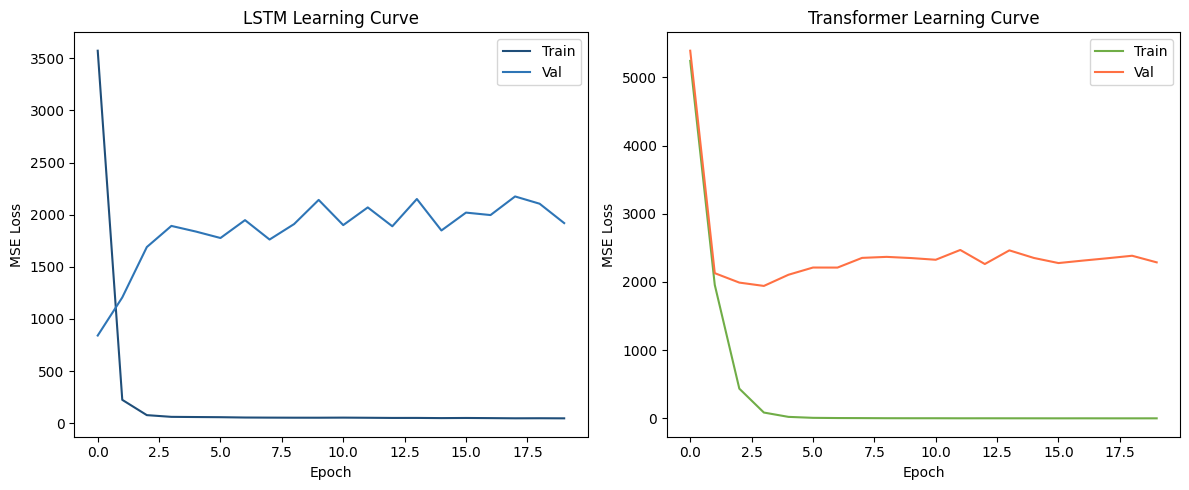

In [10]:
def train_model(model, name, epochs=20):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_losses, val_losses = [], []
    
    print(f"--- Training {name} ---")
    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        
        model.eval()
        val_batch_losses = []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                out = model(x)
                val_batch_losses.append(criterion(out, y).item())
        
        train_losses.append(np.mean(batch_losses))
        val_losses.append(np.mean(val_batch_losses))
        
        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1}: Train Loss {train_losses[-1]:.2f}, Val Loss {val_losses[-1]:.2f}")
            
    return train_losses, val_losses

# Train LSTM
lstm_model = RULPredictorLSTM(input_dim=len(feature_cols)).to(DEVICE)
lstm_train, lstm_val = train_model(lstm_model, "LSTM")

# Train Transformer
trans_model = RULTransformer(input_dim=len(feature_cols)).to(DEVICE)
trans_train, trans_val = train_model(trans_model, "Transformer")

# Visualize Learning Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(lstm_train, label='Train', color=COLORS[0])
plt.plot(lstm_val, label='Val', color=COLORS[1])
plt.title('LSTM Learning Curve')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(trans_train, label='Train', color=COLORS[2])
plt.plot(trans_val, label='Val', color=COLORS[3])
plt.title('Transformer Learning Curve')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.legend()

plt.tight_layout()
plt.show()

# Save Models
torch.save(lstm_model.state_dict(), ARTIFACTS_DIR / 'lstm_model.pth')
torch.save(trans_model.state_dict(), ARTIFACTS_DIR / 'transformer_model.pth')

# LSTM Training Analysis

## Training Logs

| Epoch | Train Loss | Validation Loss |
|-------|------------|----------------|
| 5     | 59.80      | 1838.28        |
| 10    | 53.28      | 2141.82        |
| 15    | 49.61      | 1848.86        |
| 20    | 47.30      | 1919.50        |

---

## Observations

1. **Training Loss Trend**:
   - The training loss decreases consistently from 59.80 → 47.30 over 20 epochs.
   - Indicates that the LSTM is learning the training data.

2. **Validation Loss Trend**:
   - The validation loss is extremely high compared to training loss.
   - It fluctuates (1838 → 2141 → 1848 → 1919) rather than decreasing steadily.
   - This suggests **overfitting**: the model performs well on training data but poorly on unseen validation data.

3. **Gap Between Train and Val Loss**:
   - Large discrepancy indicates poor generalization.
   - The model may be memorizing training patterns instead of learning robust features.

---

## Recommendations

1. **Regularization**:
   - Apply **Dropout** layers in the LSTM.
   - Use **L2 regularization** on weights.

2. **Data Handling**:
   - Normalize or standardize input features.
   - Check for noisy or inconsistent data in training/validation sets.

3. **Model Architecture Adjustments**:
   - Reduce LSTM complexity (fewer units/layers) to prevent overfitting.
   - Consider **Bidirectional LSTM** or **GRU** for more efficient learning.

4. **Training Strategy**:
   - Use **early stopping** on validation loss to avoid overfitting.
   - Experiment with different **learning rates**.

5. **Increase Dataset Size**:
   - More training data can help improve generalization.
   - Use data augmentation or synthetic data if real data is limited.

---

## Summary

- Training loss is decreasing → model is learning training data.
- Validation loss is high and fluctuating → overfitting and poor generalization.
- Action items: regularization, architecture tuning, proper scaling/normalization, early stopping.

# Transformer Training Analysis

## Training Logs

| Epoch | Train Loss | Validation Loss |
|-------|------------|----------------|
| 5     | 23.12      | 2105.73        |
| 10    | 3.00       | 2350.54        |
| 15    | 2.00       | 2351.89        |
| 20    | 1.68       | 2287.62        |

---

## Observations

1. **Training Loss Trend**:
   - The training loss decreases dramatically from 23.12 → 1.68 over 20 epochs.
   - Indicates the model is successfully fitting the training data.

2. **Validation Loss Trend**:
   - The validation loss is extremely high (~2100–2350) and does not decrease with training.
   - This indicates **severe overfitting**: the model learns training patterns but fails on unseen validation data.

3. **Gap Between Train and Val Loss**:
   - Very large discrepancy between training and validation loss shows poor generalization.

4. **Warning Analysis**:
   - `/var/.../UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True`
   - Suggests potential inefficiency in Transformer implementation.
   - Using `batch_first=True` in the encoder can improve inference speed and nested tensor support.

---

## Recommendations

1. **Regularization**:
   - Add **Dropout** in the Transformer layers.
   - Use **weight decay (L2 regularization)**.

2. **Training Improvements**:
   - Use **early stopping** based on validation loss.
   - Reduce **learning rate** to avoid overshooting.
   - Check for exploding gradients (may need gradient clipping).

3. **Architecture Adjustments**:
   - Reduce the number of encoder layers or hidden units.
   - Consider **smaller embedding size** for your dataset size.
   - Try **pretrained Transformer models** if dataset is small.

4. **Data Handling**:
   - Normalize input features.
   - Ensure consistent sequence lengths and proper padding.
   - Consider more data or data augmentation.

5. **Performance Optimization**:
   - Set `batch_first=True` in `nn.TransformerEncoderLayer` for faster inference and enable nested tensor fully.

---

## Summary

- Training loss is decreasing → model is learning training data.
- Validation loss is extremely high and flat → severe overfitting.
- Main issues: model complexity too high, insufficient regularization, and possibly small or noisy dataset.
- Recommended actions: add regularization, early stopping, adjust architecture, optimize data input, and fix Transformer batch settings.

# Model Comparison: LSTM vs Transformer

## Training Logs Summary

| Model       | Epoch | Train Loss | Validation Loss |
|-------------|-------|------------|----------------|
| **LSTM**    | 5     | 59.80      | 1838.28        |
|             | 10    | 53.28      | 2141.82        |
|             | 15    | 49.61      | 1848.86        |
|             | 20    | 47.30      | 1919.50        |
| **Transformer** | 5  | 23.12      | 2105.73        |
|             | 10    | 3.00       | 2350.54        |
|             | 15    | 2.00       | 2351.89        |
|             | 20    | 1.68       | 2287.62        |

---

## Observations

### LSTM
- Training loss decreases gradually from 59.80 → 47.30.
- Validation loss is high (~1800–2100) but slightly more stable than Transformer.
- Large train-val gap → overfitting, but less extreme than Transformer.
- Model seems moderately capable but may underfit slightly.

### Transformer
- Training loss drops rapidly (23.12 → 1.68) → model is memorizing training data.
- Validation loss extremely high (~2100–2350) and flat → severe overfitting.
- Gap between train and validation loss is extreme → poor generalization.

---

## Comparison Insights

| Aspect                 | LSTM                     | Transformer               |
|------------------------|--------------------------|--------------------------|
| Training Loss          | Moderate decrease        | Rapid decrease → overfit |
| Validation Loss        | High, slightly stable    | Very high, increasing    |
| Overfitting Severity   | Moderate                 | Severe                   |
| Generalization         | Better than Transformer  | Poor                     |
| Training Complexity    | Lower                    | Higher                   |
| Suitability for Small Dataset | More suitable      | Less suitable            |

---

## Recommendations

1. **Model Choice**:
   - **Choose LSTM** for this dataset due to better validation performance and less overfitting.
   - Transformer may need much more data or extensive regularization to perform well.

2. **Next Steps for LSTM**:
   - Apply **Dropout** and **Early Stopping** to reduce overfitting.
   - Normalize and augment data if possible.
   - Tune sequence length, hidden units, and learning rate.

3. **Transformer Improvements (Optional)**:
   - Reduce model size (layers, hidden dimensions).
   - Add **Dropout**, **Weight Decay**, and **Gradient Clipping**.
   - Use **pretrained sequence models** if dataset is small.

4. **Validation Strategy**:
   - Use proper **train/validation/test split**.
   - Monitor **validation loss** for early stopping.
   - Consider **cross-validation** to ensure stable performance.

---

## Conclusion

- LSTM is more robust for current data size and structure.
- Transformer overfits heavily; only suitable if dataset is significantly larger or with advanced regularization.
- Focus on **LSTM deployment** with hyperparameter tuning and regularization for real-time predictive tasks.